In [374]:
import pandas as pd
import numpy as np

In [375]:
df = pd.read_csv("C:\\Users\\user\\Desktop\\end to end ML project\\notebook\\data\\stud.csv")

## Feature Engineering

### Feature Transformation

Finding the distribution of data 

In [376]:
numerical_cols = df.select_dtypes(exclude="object").columns
categorical_cols = df.select_dtypes(include="object").columns

In [377]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [378]:
for col in ['reading_score', 'writing_score']:
    lower = df[col].quantile(0.025)
    upper = df[col].quantile(0.975)

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Filtered Shape:", df.shape)

Filtered Shape: (909, 8)


In [379]:
# EXAMPLE OF FUNCTION TRANSFORMER:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Define a custom function to calculate the square of the input data
def square_func(X):
    return np.square(X)

# Create a function transformer using the custom function
square_transformer = FunctionTransformer(func=square_func)

X = df.drop(columns= ['math_score'])
y = df['math_score']
X[['reading_score', 'writing_score']] = square_transformer.fit_transform(X[['reading_score', 'writing_score']])

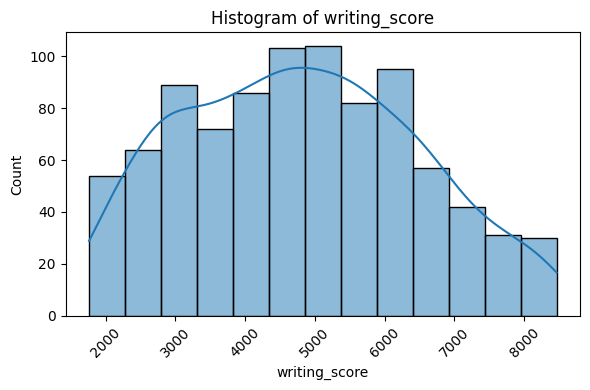

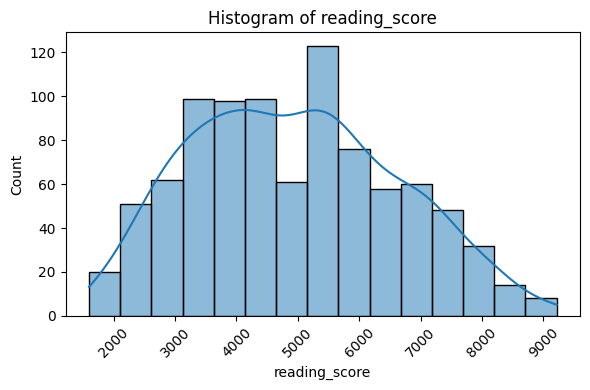

In [380]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in ['writing_score', 'reading_score']:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=X, x=col, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Handling outliers

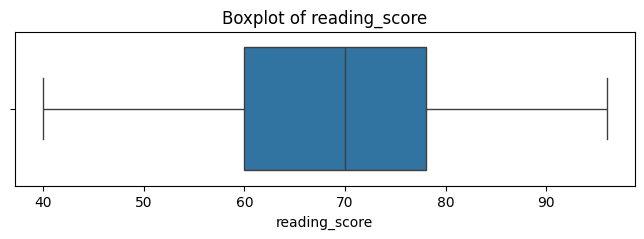

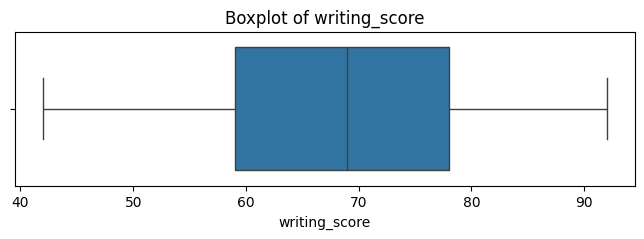

In [381]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = X.select_dtypes(include="number").columns

for col in numerical_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [382]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()

In [383]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78


In [384]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [385]:
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

In [386]:
X_train.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
96,male,group B,some high school,standard,completed,-0.347145,-0.558197
12,female,group B,high school,standard,none,0.965895,0.323664
678,male,group D,associate's degree,free/reduced,none,0.408523,0.772017
278,female,group C,some high school,free/reduced,none,1.463124,0.959672
955,male,group E,associate's degree,standard,none,-1.006345,-0.558197


In [387]:
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
X_test.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
951,female,group D,some college,standard,completed,0.589550,1.250063
486,male,group D,some college,free/reduced,none,-1.625648,-0.978639
380,female,group B,associate's degree,standard,none,1.463124,1.250063
808,male,group C,high school,standard,none,0.408523,-0.013640
863,female,group C,some college,standard,completed,0.060761,0.959672


In [388]:
df["gender"].value_counts()

gender
female    458
male      451
Name: count, dtype: int64

In [389]:
df["race_ethnicity"].value_counts()

race_ethnicity
group C    294
group D    238
group B    174
group E    121
group A     82
Name: count, dtype: int64

In [390]:
df["parental_level_of_education"].value_counts()

parental_level_of_education
some college          206
associate's degree    203
high school           183
some high school      162
bachelor's degree     104
master's degree        51
Name: count, dtype: int64

In [391]:
df["lunch"].value_counts()

lunch
standard        591
free/reduced    318
Name: count, dtype: int64

In [392]:
df['test_preparation_course'].value_counts()

test_preparation_course
none         585
completed    324
Name: count, dtype: int64

In [393]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_encoded = encoder.fit_transform(X_train[categorical_cols])
test_encoded = encoder.transform(X_test[categorical_cols])

train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

X_train = pd.concat([X_train, train_encoded_df], axis=1)
X_test = pd.concat([X_test, test_encoded_df], axis=1)

print(X_train.head())
print(X_train.shape)
print(X_test.shape)

     reading_score  writing_score  gender_female  gender_male  \
96       -0.347145      -0.558197            0.0          1.0   
12        0.965895       0.323664            1.0          0.0   
678       0.408523       0.772017            0.0          1.0   
278       1.463124       0.959672            1.0          0.0   
955      -1.006345      -0.558197            0.0          1.0   

     race_ethnicity_group A  race_ethnicity_group B  race_ethnicity_group C  \
96                      0.0                     1.0                     0.0   
12                      0.0                     1.0                     0.0   
678                     0.0                     0.0                     0.0   
278                     0.0                     0.0                     1.0   
955                     0.0                     0.0                     0.0   

     race_ethnicity_group D  race_ethnicity_group E  \
96                      0.0                     0.0   
12                      

In [394]:
X_train.shape

(727, 19)

In [395]:
X_test.shape

(182, 19)

In [416]:
X_train,X_val,y_train,y_val= train_test_split(X_train, y_train, test_size=0.2,random_state=42)

In [442]:
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score

In [449]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical(
        "regressor",
        [
            "LinearRegression",
            "ElasticNet",
            "Ridge",
            "SVR",
            "DecisionTreeRegressor",
            "RandomForest",
            "AdaBoost",
            "GradientBoosting",
            "XGBoost",
            "Voting",
            "Stacking"
        ]
    )

    if classifier_name == 'LinearRegression':
        # LR hyperparameters

        model = LinearRegression()

    elif classifier_name == 'ElasticNet':
        # ElasticNet hyperparameters
        alpha = trial.suggest_float('alpha', 0.001, 100)
        l1_ratio = trial.suggest_float('l1_ratio', 0, 1.0)
        max_iter = trial.suggest_int('max_iter', 100, 1000)

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=max_iter
        )

    elif classifier_name == 'Ridge':
        # Ridge hyperparameters
        max_iter = trial.suggest_int('max_iter', 100, 1000)
        alpha = trial.suggest_float('alpha', 0.001, 100.0)

        model = Ridge(
            max_iter=max_iter,
            alpha = alpha,
        )

    elif classifier_name == 'SVR':
        # SVR hyperparameters
        C = trial.suggest_float('C', 0.001, 100.0)
        max_iter = trial.suggest_int('max_iter', 100, 1000)

        model = SVR(
            C = C,
            max_iter=max_iter,
        )
        
    elif classifier_name == 'DecisionTreeRegressor':
        # DT hyperparameters
        criterion = trial.suggest_categorical("criterion", ["squared_error", "absolute_error", "poisson"])
        splitter = trial.suggest_categorical("splitter", ["best", "random"])
        max_depth = trial.suggest_int("max_depth",2,1000)
        min_samples_split = trial.suggest_int("min_samples_split", 2,100)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2,100)

        model = DecisionTreeRegressor(
            criterion=criterion,
            splitter=splitter,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            max_leaf_nodes=max_leaf_nodes
        )
    
    elif classifier_name == "RandomForest":

        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 2, 50)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        )

    elif classifier_name == "AdaBoost":

        n_estimators = trial.suggest_int("n_estimators", 50, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 1.0, log=True)

        model = AdaBoostRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=42
        )

    elif classifier_name == "GradientBoosting":

        n_estimators = trial.suggest_int("n_estimators", 50, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.5, log=True)
        max_depth = trial.suggest_int("max_depth", 2, 10)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)

        model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            random_state=42
        )

    elif classifier_name == "XGBoost":

        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 2, 10)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)

        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

    elif classifier_name == "Voting":

        model = VotingRegressor(
            estimators=[
                ("lr", LinearRegression()),
                ("ridge", Ridge()),
                ("rf", RandomForestRegressor(random_state=42)),
            ]
        )

    elif classifier_name == "Stacking":

        estimators = [
            ("ridge", Ridge()),
            ("rf", RandomForestRegressor(random_state=42)),
            ("svr", make_pipeline(StandardScaler(), SVR()))
        ]

        model = StackingRegressor(
            estimators=estimators,
            final_estimator=LinearRegression(),
            n_jobs=-1
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2').mean()
    return score

In [450]:
# Create a study and optimize it using CmaEsSampler
import optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=350)

[I 2026-07-21 22:03:36,043] A new study created in memory with name: no-name-b89efa9e-8c1d-4dfc-8603-4bbe7281816d
[I 2026-07-21 22:03:36,076] Trial 0 finished with value: 0.7676013881879514 and parameters: {'regressor': 'Ridge', 'max_iter': 618, 'alpha': 66.89238500638047}. Best is trial 0 with value: 0.7676013881879514.
c:\Users\user\Desktop\end to end ML project\venv\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=910).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\user\Desktop\end to end ML project\venv\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=910).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\user\Desktop\end to end ML project\venv\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=910).  Consider pre-processing your data with 

In [451]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'regressor': 'Ridge', 'max_iter': 182, 'alpha': 3.445218538709996}
Best trial accuracy: 0.8121817598528254


In [452]:
best_params = study.best_trial.params

regressor = best_params.pop("regressor")

In [454]:
regressor

'Ridge'

In [456]:
ridge = Ridge(**best_params)

In [457]:
ridge.fit(X_train,y_train)
preds = ridge.predict(X_test)

In [459]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("RMSE: ", np.sqrt(mean_squared_error(y_test,preds)))
print("mae: ", mean_absolute_error(y_test, preds))
print("R2 score: ", r2_score(y_test, preds))

RMSE:  5.5323357448199575
mae:  4.39003328113125
R2 score:  0.8230710726416928
